# Filtros de suavizado y reducción de ruido

En este cuaderno vas a comparar distintos filtros de suavizado sobre imágenes con ruido controlado. La idea central es que no todos los ruidos se corrigen igual ni todos los filtros preservan el detalle de la misma manera.


## Objetivo

Entender qué tipo de ruido intenta resolver cada filtro y qué costo visual tiene esa corrección.

## Resultados de aprendizaje

Al finalizar este cuaderno, vas a poder:

- distinguir ruido gaussiano y ruido sal y pimienta;
- aplicar filtros promedio, gaussiano, mediana y bilateral;
- comparar cuál funciona mejor según el tipo de degradación;
- describir la relación entre suavizado y pérdida de detalle.

## Relación con la secuencia

Este cuaderno se ubica después de mejora de imagen y antes de operaciones morfológicas e inpainting. La idea es trabajar primero con filtros que modifican intensidades vecinas y después pasar a limpiezas más específicas.


## Módulos que vamos a usar

- `cv2`: para aplicar filtros de suavizado.
- `numpy`: para construir ruidos controlados.
- `matplotlib.pyplot`: para comparar resultados.
- `pathlib.Path`: para cargar la imagen de trabajo.


In [9]:
# Se importan las bibliotecas necesarias para manejar rutas de archivos,
# leer y procesar im?genes con OpenCV, trabajar con arreglos numéricos
# y visualizar resultados con Matplotlib.
from pathlib import Path

import cv2
import numpy as np
import matplotlib.pyplot as plt

# Se define la ruta de la imagen de entrada usando Path para que
# el manejo de directorios y archivos sea m?s claro y portable.
ruta_imagen = Path("Imagenes") / "lena.jpg"

# Se carga la imagen en formato color. OpenCV la lee por defecto en BGR.
imagen_bgr = cv2.imread(str(ruta_imagen), cv2.IMREAD_COLOR)

# Se verifica que la imagen se haya cargado correctamente.
# Si no se pudo leer, se lanza un error indicando la ruta.
if imagen_bgr is None:
    raise FileNotFoundError(f"No se pudo leer la imagen: {ruta_imagen}")

# Se convierte la imagen desde el espacio de color BGR a RGB
# para poder visualizarla correctamente con Matplotlib.
imagen_rgb = cv2.cvtColor(imagen_bgr, cv2.COLOR_BGR2RGB)

# Se genera una versión en escala de grises, útil para estudiar
# el efecto del ruido y de los filtros sin la complejidad del color.
imagen_gris = cv2.cvtColor(imagen_bgr, cv2.COLOR_BGR2GRAY)


## 1. Imagen de referencia

Primero miramos la imagen original. Después vamos a degradarla de manera controlada para comparar cómo responde cada filtro.


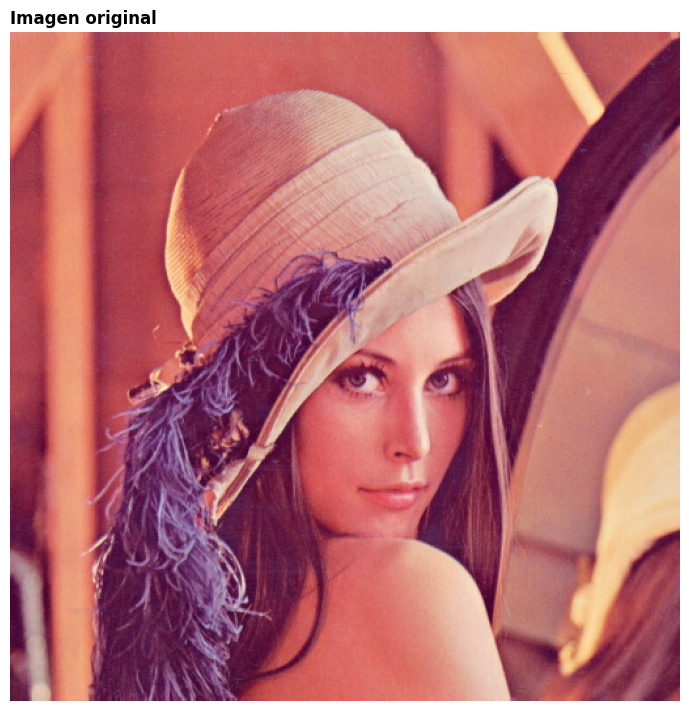

In [10]:
# Esta figura establece una referencia visual antes de degradar la imagen.
# Mirar la escena original ayuda a notar despu?s qu? detalle se pierde.
plt.figure(figsize=(7, 7), constrained_layout=True)
plt.imshow(imagen_rgb)
plt.title("Imagen original", fontweight="bold", loc="left")
plt.axis("off")
plt.show()


## 2. Crear dos tipos de ruido

Vamos a generar dos degradaciones sintéticas:

- ruido gaussiano, que altera suavemente muchos píxeles;
- ruido sal y pimienta, que introduce puntos muy claros y muy oscuros.


In [ ]:
# Se importa el módulo estándar random para evitar depender de
# numpy.random, que en este entorno está bloqueado por una política del sistema.
import random

# Se fijan semillas para que la generación del ruido sea reproducible.
# OpenCV se usa para el ruido gaussiano y random para sal y pimienta.
cv2.setRNGSeed(42)
random.seed(42)

# Se genera ruido gaussiano con media 0 y desvío estándar 18
# usando el generador interno de OpenCV.
ruido_gaussiano = np.zeros(imagen_gris.shape, dtype=np.float32)
cv2.randn(ruido_gaussiano, 0, 18)

# El ruido se suma a la imagen original. Luego se recortan los valores
# al rango válido [0, 255] y se convierte nuevamente a uint8.
imagen_con_ruido_gaussiano = np.clip(
    imagen_gris.astype(np.float32) + ruido_gaussiano,
    0,
    255,
).astype(np.uint8)

# Se crea una copia de la imagen original para agregarle ruido sal y pimienta.
imagen_con_sal_pimienta = imagen_gris.copy()

# Se calcula la cantidad total de píxeles y se define que el 4%
# será alterado por el ruido.
cantidad_pixeles = imagen_gris.size
cantidad_ruido = int(0.04 * cantidad_pixeles)

# Se eligen posiciones aleatorias para los píxeles de sal y pimienta
# usando índices lineales y el generador estándar de Python.
indices_sal = random.sample(range(cantidad_pixeles), cantidad_ruido)
indices_pimienta = random.sample(range(cantidad_pixeles), cantidad_ruido)

# np.unravel_index transforma índices lineales en coordenadas
# (fila, columna) para poder escribir directamente sobre la imagen.
filas_sal, columnas_sal = np.unravel_index(indices_sal, imagen_gris.shape)
filas_pimienta, columnas_pimienta = np.unravel_index(indices_pimienta, imagen_gris.shape)

# Se asignan los valores extremos para simular sal y pimienta.
imagen_con_sal_pimienta[filas_sal, columnas_sal] = 255
imagen_con_sal_pimienta[filas_pimienta, columnas_pimienta] = 0



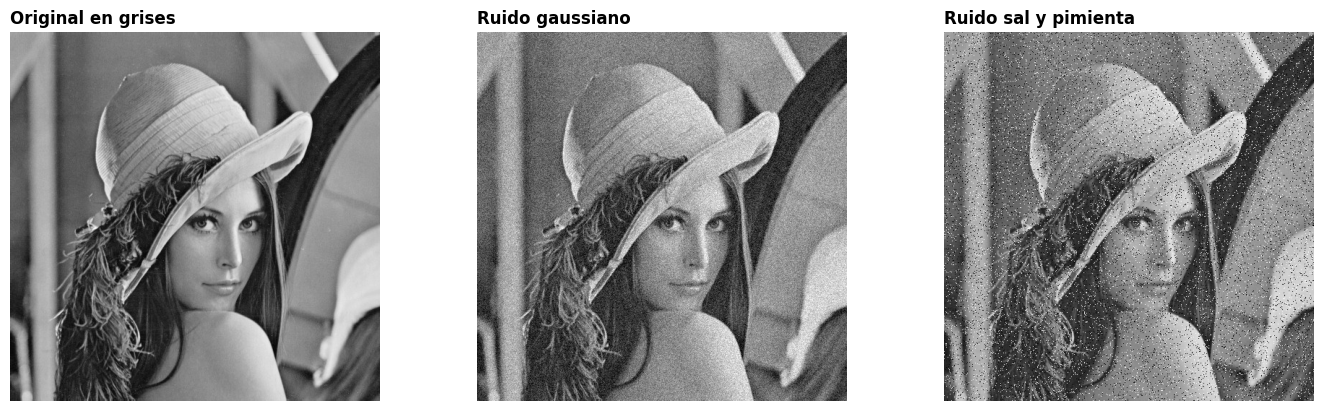

In [12]:
# Se muestran juntas la imagen original en grises y sus dos degradaciones
# para que la comparaci?n sea inmediata antes de filtrar.
fig, ejes = plt.subplots(1, 3, figsize=(14, 4), constrained_layout=True)
ejes[0].imshow(imagen_gris, cmap="gray")
ejes[0].set_title("Original en grises", fontweight="bold", loc="left")
ejes[0].axis("off")
ejes[1].imshow(imagen_con_ruido_gaussiano, cmap="gray")
ejes[1].set_title("Ruido gaussiano", fontweight="bold", loc="left")
ejes[1].axis("off")
ejes[2].imshow(imagen_con_sal_pimienta, cmap="gray")
ejes[2].set_title("Ruido sal y pimienta", fontweight="bold", loc="left")
ejes[2].axis("off")
plt.show()


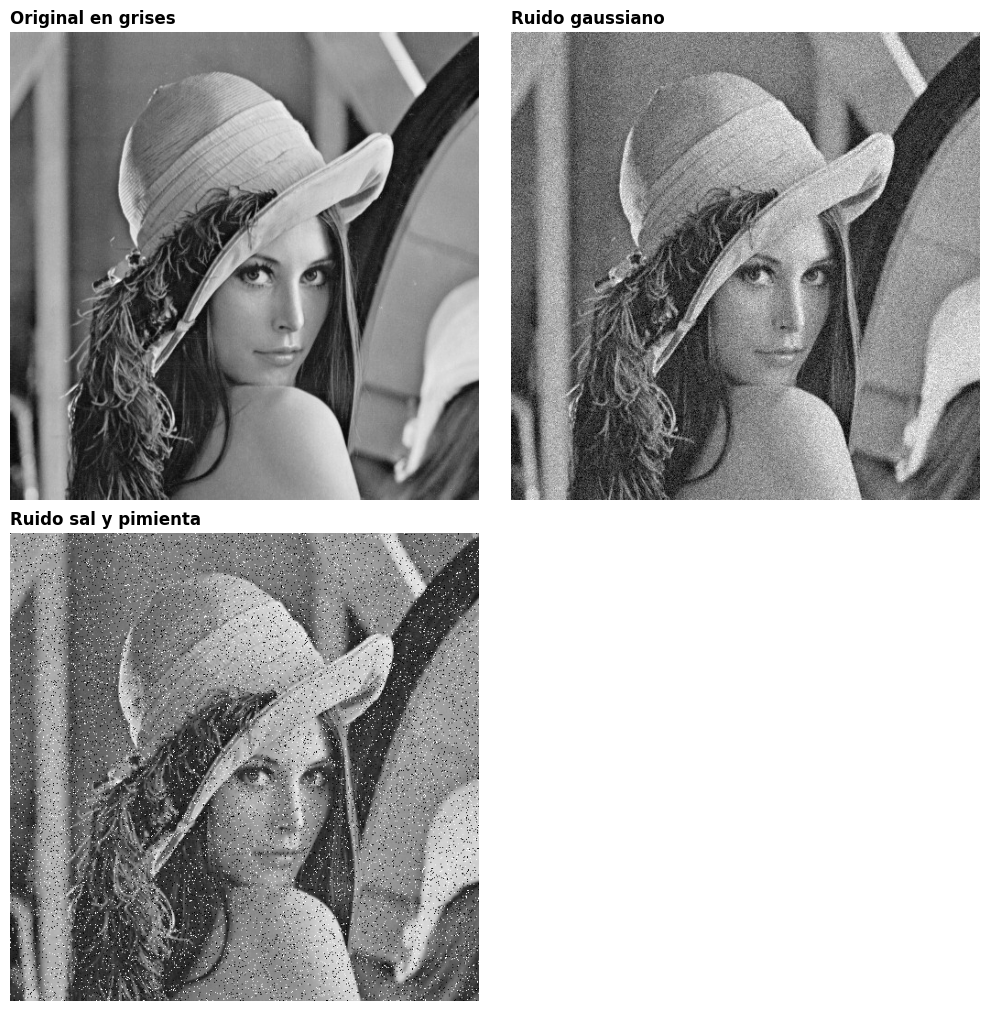

In [13]:
fig, ejes = plt.subplots(2, 2, figsize=(10, 10), constrained_layout=True)

ejes[0, 0].imshow(imagen_gris, cmap="gray")
ejes[0, 0].set_title("Original en grises", fontweight="bold", loc="left")
ejes[0, 0].axis("off")

ejes[0, 1].imshow(imagen_con_ruido_gaussiano, cmap="gray")
ejes[0, 1].set_title("Ruido gaussiano", fontweight="bold", loc="left")
ejes[0, 1].axis("off")

ejes[1, 0].imshow(imagen_con_sal_pimienta, cmap="gray")
ejes[1, 0].set_title("Ruido sal y pimienta", fontweight="bold", loc="left")
ejes[1, 0].axis("off")

ejes[1, 1].axis("off")

plt.show()


## 3. Aplicar filtros de suavizado

Ahora vamos a comparar cuatro filtros comunes. No todos responden igual frente a cada degradación.


In [15]:
# Filtro promedio: suaviza calculando el promedio local de cada vecindad.
promedio_gaussiano = cv2.blur(imagen_con_ruido_gaussiano, (5, 5))

# Filtro gaussiano: pondera más a los píxeles cercanos al centro.
gaussiano_gaussiano = cv2.GaussianBlur(imagen_con_ruido_gaussiano, (5, 5), 0)

# Filtro mediana: reemplaza por el valor mediano de la vecindad,
# especialmente útil contra ruido impulsivo como sal y pimienta.
mediana_gaussiano = cv2.medianBlur(imagen_con_ruido_gaussiano, 5)

# Filtro bilateral: suaviza, pero intenta preservar bordes fuertes.
bilateral_gaussiano = cv2.bilateralFilter(imagen_con_ruido_gaussiano, 9, 50, 50)

# Se repite la misma batería de filtros sobre la imagen con ruido sal y pimienta
# para poder comparar qué estrategia responde mejor a este caso.
promedio_sal = cv2.blur(imagen_con_sal_pimienta, (5, 5))
gaussiano_sal = cv2.GaussianBlur(imagen_con_sal_pimienta, (5, 5), 0)
mediana_sal = cv2.medianBlur(imagen_con_sal_pimienta, 5)
bilateral_sal = cv2.bilateralFilter(imagen_con_sal_pimienta, 9, 50, 50)


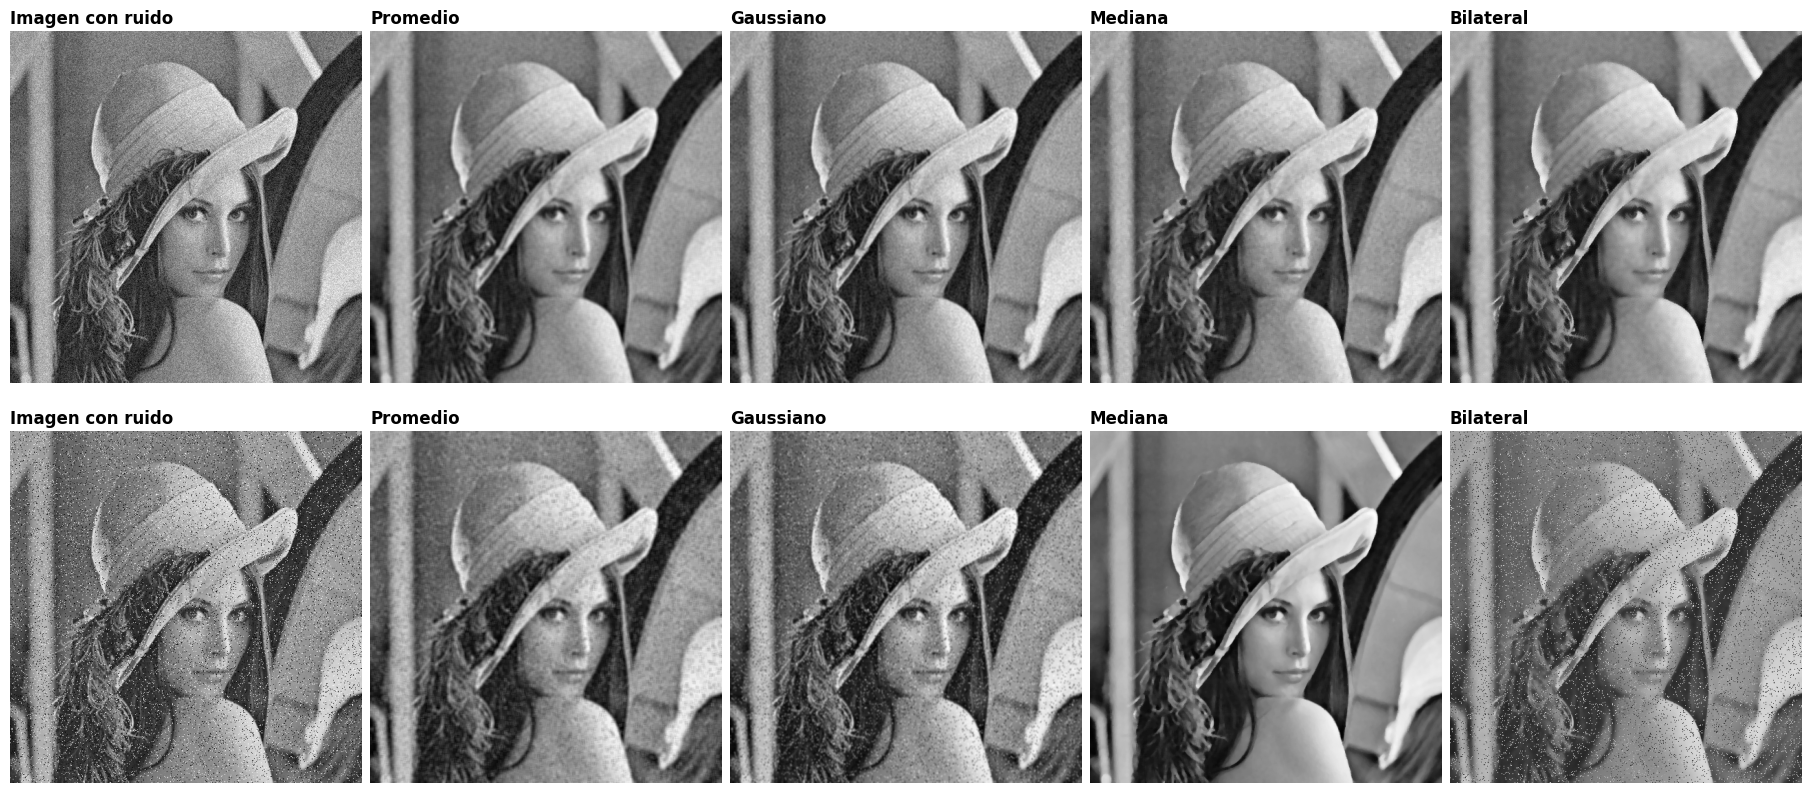

In [ ]:
# La primera fila muestra la respuesta de cada filtro frente a ruido gaussiano.
# La segunda fila muestra la misma comparación para sal y pimienta.
fig, ejes = plt.subplots(2, 5, figsize=(18, 8), constrained_layout=True)

titulos = [
    "Imagen con ruido",
    "Promedio",
    "Gaussiano",
    "Mediana",
    "Bilateral",
]

imagenes_fila_1 = [
    imagen_con_ruido_gaussiano,
    promedio_gaussiano,
    gaussiano_gaussiano,
    mediana_gaussiano,
    bilateral_gaussiano,
]

imagenes_fila_2 = [
    imagen_con_sal_pimienta,
    promedio_sal,
    gaussiano_sal,
    mediana_sal,
    bilateral_sal,
]

for indice, imagen in enumerate(imagenes_fila_1):
    ejes[0, indice].imshow(imagen, cmap="gray")
    ejes[0, indice].set_title(titulos[indice], fontweight="bold", loc="left")
    ejes[0, indice].axis("off")

for indice, imagen in enumerate(imagenes_fila_2):
    ejes[1, indice].imshow(imagen, cmap="gray")
    ejes[1, indice].set_title(titulos[indice], fontweight="bold", loc="left")
    ejes[1, indice].axis("off")

plt.show()


Compará por filas. En general, el filtro gaussiano suele responder bien al ruido gaussiano, mientras que la mediana suele funcionar mejor frente al ruido sal y pimienta. El bilateral intenta suavizar sin borrar tanto los bordes, pero no siempre resulta el más simple de interpretar.


## 4. Mirar un recorte pequeño

Un recorte ayuda a detectar mejor qué filtro conserva borde, qué filtro emborrona y qué filtro elimina mejor el ruido puntual.


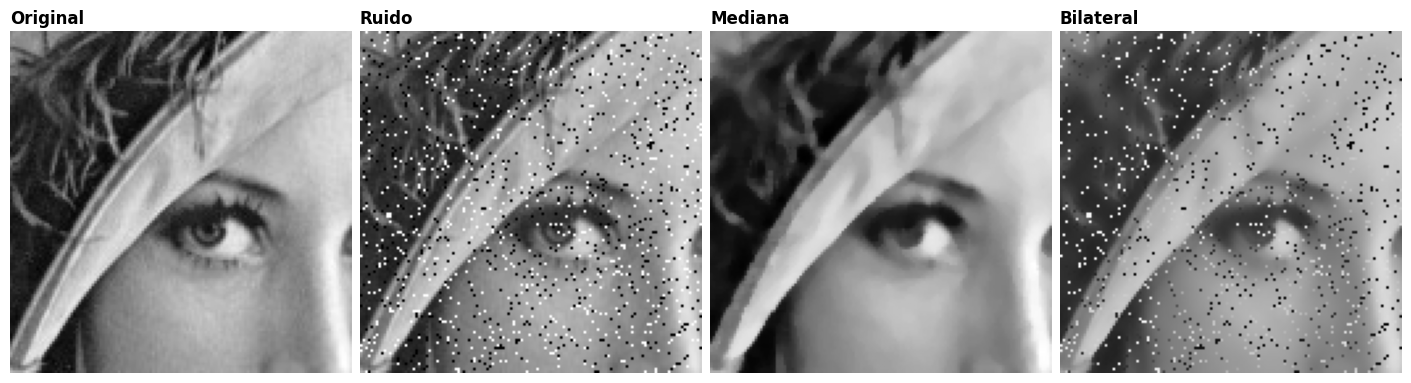

In [17]:
# Se define un recorte para mirar detalle fino en una zona concreta.
# Esto facilita ver qu? filtro conserva mejor los bordes locales.
fila_inicial, fila_final = 190, 320
columna_inicial, columna_final = 190, 320

recorte_original = imagen_gris[fila_inicial:fila_final, columna_inicial:columna_final]
recorte_ruido = imagen_con_sal_pimienta[fila_inicial:fila_final, columna_inicial:columna_final]
recorte_mediana = mediana_sal[fila_inicial:fila_final, columna_inicial:columna_final]
recorte_bilateral = bilateral_sal[fila_inicial:fila_final, columna_inicial:columna_final]

fig, ejes = plt.subplots(1, 4, figsize=(14, 4), constrained_layout=True)
recortes = [recorte_original, recorte_ruido, recorte_mediana, recorte_bilateral]
titulos = ["Original", "Ruido", "Mediana", "Bilateral"]

for eje, imagen, titulo in zip(ejes, recortes, titulos):
    eje.imshow(imagen, cmap="gray")
    eje.set_title(titulo, fontweight="bold", loc="left")
    eje.axis("off")
plt.show()


## Actividad breve

Elegí uno de los dos tipos de ruido y escribe una comparación breve entre dos filtros. Indica:

1. cuál elimina mejor el ruido;
La **mediana** elimina mejor el ruido porque reemplaza los puntos aislados extremos por valores m?s representativos de la vecindad. En este caso saca gran parte de los puntitos blancos y negros dispersos.
2. cuál conserva mejor el borde;
El **bilateral** conserva un poco mejor algunos bordes suaves, pero deja pasar m?s ruido impulsivo. En la pr?ctica, la **mediana** logra un equilibrio mejor porque limpia mucho y todav?a mantiene la estructura principal del objeto.
3. cuál usarías si después tuvieras que detectar contornos.
Si después tuviera que **detectar contornos**, usaría la **mediana**, porque entrega una imagen más limpia y con menos puntos falsos que podrían transformarse en contornos espurios.


## Cierre

Suavizar no significa simplemente “mejorar”. Cada filtro reduce algunas variaciones y al mismo tiempo borra parte del detalle. La pregunta útil no es qué filtro es más fuerte, sino qué filtro deja la imagen mejor preparada para la tarea que sigue.
